In [1]:
!pip install imageio pillow -q

In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.distributions import MultivariateNormal, OneHotCategorical, Categorical
from PIL import Image, ImageDraw
import imageio
import base64
from IPython.display import display, HTML
from PIL import Image, ImageDraw
# torch.manual_seed(1337)

In [3]:
DATA_DIR = "jl_fs/stroke/npz" # ← folder that contains the .npz files
data_classes = [
 "airplane", "apple", "axe", "banana", "bed",
 "bicycle", "car", "clock", "fish", "tree",
]
num_classes = len(data_classes) 

In [4]:
batch_size = 64
training_iters = 50000
eval_interval = training_iters // 20 # print loss every 1200 steps
learning_rate = 1e-4
device = "cuda" if torch.cuda.is_available() else "cpu"
eval_iters = 10
embd = 384
embd_ffn = 4 * embd
num_heads = 6
n_layers = 6
dropout = 0.2
n_components = 20 # gaussians in MDN
print(f"Using device: {device}")
print(f"Classes: {data_classes}")

Using device: cuda
Classes: ['airplane', 'apple', 'axe', 'banana', 'bed', 'bicycle', 'car', 'clock', 'fish', 'tree']


In [5]:
def load_local_quickdraw(data_dir: str, classes: list):
    """
    Load Quick Draw .npz files from a local directory.
    Each file must be named  <class_name>.npz  and contain
    keys 'train', 'valid', 'test' (same format as the sketchrnn dataset).
 
    Returns six lists:
        train_set, train_labels,
        valid_set, valid_labels,
        test_set,  test_labels
    """
    train_set, valid_set, test_set          = [], [], []
    train_labels, valid_labels, test_labels = [], [], []
 
    for class_idx, class_name in enumerate(classes):
        npz_path = os.path.join(data_dir, f"{class_name}.npz")
        if not os.path.exists(npz_path):
            raise FileNotFoundError(
                f"Could not find '{npz_path}'. "
                f"Make sure '{class_name}.npz' is inside '{data_dir}'."
            )
 
        npz = np.load(npz_path, allow_pickle=True, encoding="latin1")
 
        n_train = len(npz["train"])
        n_valid = len(npz["valid"])
        n_test  = len(npz["test"])
 
        train_set    += npz["train"].tolist()
        valid_set    += npz["valid"].tolist()
        test_set     += npz["test"].tolist()
 
        train_labels += [class_idx] * n_train
        valid_labels += [class_idx] * n_valid
        test_labels  += [class_idx] * n_test
 
        print(f"  [{class_idx:2d}] {class_name:<10s}  "
              f"train={n_train}  valid={n_valid}  test={n_test}")
 
    return (train_set, train_labels,
            valid_set, valid_labels,
            test_set,  test_labels)
 
 
print("Loading data from local folder ...")
(train_set, train_labels,
 valid_set, valid_labels,
 test_set,  test_labels) = load_local_quickdraw(DATA_DIR, data_classes)
 
print(f"\nTotal  train={len(train_set)}  valid={len(valid_set)}  test={len(test_set)}")
 
# ── Compute block_size and normalisation constants from training data ──────────
max_len    = max(len(x) for x in train_set)
block_size = min(max_len, 250)
 
x_var, y_var, N = 0.0, 0.0, 0
for x in train_set:
    x_var += float((x[:, 0] ** 2).sum())
    y_var += float((x[:, 1] ** 2).sum())
    N     += len(x)
x_std = float(np.sqrt(x_var / N))
y_std = float(np.sqrt(y_var / N))
 
print(f"\nblock_size = {block_size}  |  x_std = {x_std:.3f}  |  y_std = {y_std:.3f}")

Loading data from local folder ...
  [ 0] airplane    train=70000  valid=2500  test=2500
  [ 1] apple       train=70000  valid=2500  test=2500
  [ 2] axe         train=70000  valid=2500  test=2500
  [ 3] banana      train=70000  valid=2500  test=2500
  [ 4] bed         train=70000  valid=2500  test=2500
  [ 5] bicycle     train=70000  valid=2500  test=2500
  [ 6] car         train=70000  valid=2500  test=2500
  [ 7] clock       train=70000  valid=2500  test=2500
  [ 8] fish        train=70000  valid=2500  test=2500
  [ 9] tree        train=70000  valid=2500  test=2500

Total  train=700000  valid=25000  test=25000

block_size = 176  |  x_std = 33.478  |  y_std = 31.772


In [6]:
def get_batch(split: str):
    """
    Returns:
        xs      (B, T, 3)   normalised stroke-3 input sequences
        ys      (B, T, 3)   targets shifted by 1
        mask    (B, T)      True for real strokes, False for padding
        cls_ids (B,)        integer class label per sample
    """
    if split == "train":
        data, labels = train_set, train_labels
    elif split == "valid":
        data, labels = valid_set, valid_labels
    else:
        data, labels = test_set, test_labels
 
    ix = torch.randint(len(data), (batch_size,))
    xs, ys, lengths, cls_ids = [], [], [], []
 
    for i in ix.tolist():
        raw              = data[i]                          # numpy (L, 3)
        x_raw, y_raw, p = torch.tensor(raw, dtype=torch.float32).T
 
        x_norm = torch.clamp(x_raw, -1000, 1000) / x_std
        y_norm = torch.clamp(y_raw, -1000, 1000) / y_std
        p[-1]  = 2.                                         # ensure EOS token
 
        d = torch.stack([x_norm, y_norm, p], dim=-1)       # (L, 3)
        L = len(d)
 
        pad_x = torch.tensor([0., 0., 2.]).repeat(block_size - L, 1)
        xs.append(torch.cat([d, pad_x], dim=0))            # (block_size, 3)
 
        pad_y = torch.tensor([0., 0., 2.]).repeat(block_size + 1 - L, 1)
        ys.append(torch.cat([d[1:], pad_y], dim=0))        # (block_size, 3)
 
        lengths.append(L)
        cls_ids.append(labels[i])
 
    xs      = torch.stack(xs).to(device)                   # (B, T, 3)
    ys      = torch.stack(ys).to(device)                   # (B, T, 3)
    lengths = torch.tensor(lengths)                        # (B,)
    cls_ids = torch.tensor(cls_ids, dtype=torch.long).to(device)  # (B,)
 
    mask = (torch.arange(block_size).unsqueeze(0)
            <= lengths.unsqueeze(1)).to(device)            # (B, T)
 
    return xs, ys, mask, cls_ids

In [7]:
_xs, _ys, _mask, _cls = get_batch("train")
print(f"Batch  xs={_xs.shape}  ys={_ys.shape}  mask={_mask.shape}  cls={_cls.shape}")
print(f"Sample classes: {[data_classes[c] for c in _cls[:8].tolist()]}")

Batch  xs=torch.Size([64, 176, 3])  ys=torch.Size([64, 176, 3])  mask=torch.Size([64, 176])  cls=torch.Size([64])
Sample classes: ['car', 'axe', 'car', 'banana', 'bed', 'apple', 'axe', 'bed']


In [6]:
class NormalNetwork(nn.Module):
    def __init__(self, in_dim, out_dim, n_components, full_cov=True):
        super().__init__()
        self.n_components = n_components
        self.out_dim      = out_dim
        self.full_cov     = full_cov
        self.tril_indices = torch.tril_indices(out_dim, out_dim, 0)
        self.mean_net     = nn.Linear(in_dim, out_dim * n_components)
        if full_cov:
            self.tril_net = nn.Linear(
                in_dim, int(out_dim * (out_dim + 1) / 2 * n_components))
        else:
            self.tril_net = nn.Linear(in_dim, out_dim * n_components)
 
    def forward(self, x, tau=1.):
        B, T, _ = x.shape
        mean = self.mean_net(x).reshape(B, T, self.n_components, self.out_dim)
        if self.full_cov:
            tv   = self.tril_net(x).reshape(B, T, self.n_components, -1)
            tril = torch.zeros(B, T, self.n_components,
                               self.out_dim, self.out_dim, device=x.device)
            tril[:, :, :, self.tril_indices[0], self.tril_indices[1]] = tv
            tril.diagonal(dim1=-2, dim2=-1)[:] = \
                tril.diagonal(dim1=-2, dim2=-1).exp()
        else:
            tril = torch.diag_embed(
                self.tril_net(x).reshape(B, T, self.n_components, -1).exp())
        tril *= tau
        return MultivariateNormal(mean, scale_tril=tril)

In [7]:
class OneHotCategoricalNetwork(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.network = nn.Linear(in_dim, out_dim)
 
    def forward(self, x, tau=1.):
        return OneHotCategorical(logits=self.network(x) / tau)
 
 
class CategoricalNetwork(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.network = nn.Linear(in_dim, out_dim)
 
    def forward(self, x, tau=1.):
        return Categorical(logits=self.network(x) / tau)

In [8]:
class MDN(nn.Module):
    def __init__(self, dim_in, dim_out, n_components, full_cov=True):
        super().__init__()
        self.pi_net     = OneHotCategoricalNetwork(dim_in, n_components)
        self.normal_net = NormalNetwork(dim_in, dim_out, n_components, full_cov)
 
    def forward(self, x, tau=1.):
        return self.pi_net(x, tau), self.normal_net(x, tau)

In [9]:
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.query = nn.Linear(embd, head_size, bias=False)
        self.key   = nn.Linear(embd, head_size, bias=False)
        self.value = nn.Linear(embd, head_size, bias=False)
        self.register_buffer("tril",
                             torch.tril(torch.ones(block_size, block_size)))
 
    def forward(self, x):
        B, T, C = x.shape
        q   = self.query(x)
        k   = self.key(x)
        wei = (q @ k.transpose(-2, -1)) * C ** (-0.5)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float("-inf"))
        wei = F.softmax(wei, dim=-1)
        return wei @ self.value(x)
 
 
class MultiHead(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj  = nn.Linear(embd, embd)
 
    def forward(self, x):
        return self.proj(torch.cat([h(x) for h in self.heads], dim=-1))
 
 
class FeedForward(nn.Module):
    def __init__(self, embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embd, embd_ffn),
            nn.ReLU(),
            nn.Linear(embd_ffn, embd),
            nn.Dropout(dropout),
        )
 
    def forward(self, x):
        return self.net(x)
 
 
class Block(nn.Module):
    def __init__(self, embd, num_heads):
        super().__init__()
        self.sa_heads = MultiHead(num_heads, embd // num_heads)
        self.ffwd     = FeedForward(embd)
        self.ln1      = nn.LayerNorm(embd)
        self.ln2      = nn.LayerNorm(embd)
 
    def forward(self, x):
        x = x + self.sa_heads(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

In [10]:
class ClassConditionedTransformerModel(nn.Module):
    """
    Decoder-only Transformer with class conditioning.
 
    The only addition to the original TransformerModel is:
        self.class_embedding_table  <-- nn.Embedding(num_classes, embd)
 
    At every forward pass the class embedding (shape B x 1 x embd) is
    broadcast-added to every time-step's combined embedding, so the
    transformer always knows WHICH class it is drawing.
 
    All other components (MDN, Head, Block, loss formula) are identical.
    """
 
    def __init__(self):
        super().__init__()
 
        # ── original embeddings ──────────────────────────────────────────────
        self.stroke_embedding_proj    = nn.Linear(2, embd, bias=False)
        self.pen_embedding_table      = nn.Embedding(3, embd)
        self.position_embedding_table = nn.Embedding(block_size, embd)
 
        # ── NEW: one learned embedding vector per class ──────────────────────
        self.class_embedding_table    = nn.Embedding(num_classes, embd)
 
        # ── transformer backbone ─────────────────────────────────────────────
        self.blocks = nn.Sequential(
            *[Block(embd, num_heads) for _ in range(n_layers)])
        self.ln_f   = nn.LayerNorm(embd)
 
        # ── output heads ─────────────────────────────────────────────────────
        self.mdn_head = MDN(embd, 2, n_components)
        self.pen_head = CategoricalNetwork(embd, 3)
 
    def forward(self, x, class_idx, tau=1.):
        """
        x         : (B, T, 3)   stroke-3 input (normalised)
        class_idx : (B,)        integer class labels  [0 .. num_classes-1]
        tau       : float       temperature for MDN / pen distributions
        """
        B, T, _ = x.shape
 
        stroke_emb = self.stroke_embedding_proj(x[:, :, :2])      # (B, T, embd)
        pen_emb    = self.pen_embedding_table(x[:, :, 2].long())   # (B, T, embd)
        pos_emb    = self.position_embedding_table(
            torch.arange(T, device=x.device))                     # (   T, embd)
 
        # class embedding: (B, embd) -> unsqueeze -> (B, 1, embd)
        # then it is automatically broadcast over the T dimension
        cls_emb    = self.class_embedding_table(class_idx).unsqueeze(1)
 
        x = stroke_emb + pen_emb + pos_emb + cls_emb              # (B, T, embd)
 
        x = self.blocks(x)
        x = self.ln_f(x)
 
        pi_net, normal_net = self.mdn_head(x, tau=tau)
        q_net              = self.pen_head(x, tau=tau)
 
        return pi_net, normal_net, q_net
 
    def loss(self, x, targets, mask, class_idx):
        pi, normal, q = self.forward(x, class_idx)
 
        ys     = targets[:, :, :2]
        loglik = normal.log_prob(ys.unsqueeze(-2).expand_as(normal.loc))
        Ls     = -torch.logsumexp(torch.log(pi.probs) + loglik, dim=-1)
        Ls    *= mask                          # zero out padding positions
 
        yp = targets[:, :, 2]
        Lp = -q.log_prob(yp)
 
        return Ls + Lp                         # (B, T)
 
    def sample(self, x, class_idx, tau=1.):
        pi, normal, q = self.forward(x, class_idx, tau)
        s_samples = torch.sum(
            pi.sample().unsqueeze(-1) * normal.sample(), dim=-2)
        p_samples = q.sample()
        return torch.cat([s_samples, p_samples.unsqueeze(-1)], dim=-1)
 
    @torch.no_grad()
    def generate(self, x, class_idx, max_new_tokens, tau=1., break_eos=True):
        """
        x         : (1, T_start, 3)  starting context
        class_idx : (1,)             which class to draw
        """
        for _ in range(max_new_tokens):
            nxt = self.sample(x, class_idx, tau=tau)[:, -1, :].unsqueeze(1)
            x   = torch.cat([x, nxt], dim=1)
            if break_eos and int(nxt[0, 0, 2].item()) == 2:
                return x
        return x

In [11]:
def strokes_to_abs_pixels(strokes_np, factor=1.0, canvas=256):
    # Pass 1: find bounding box
    ax = ay = 0.0
    pts_raw = []
    for dx, dy, p in strokes_np:
        ax += dx
        ay += dy
        pts_raw.append([ax, ay, p])
    
    pts_raw = np.array(pts_raw)
    min_x, min_y = pts_raw[:, 0].min(), pts_raw[:, 1].min()
    max_x, max_y = pts_raw[:, 0].max(), pts_raw[:, 1].max()
    
    # Calculate scale to fit 80% of the canvas
    range_x = max(max_x - min_x, 1e-5)
    range_y = max(max_y - min_y, 1e-5)
    scale = (canvas * 0.8) / max(range_x, range_y)
    
    # Pass 2: Center and Scale
    pts = []
    for x, y, p in pts_raw:
        # Normalize to 0-1 then scale to canvas
        curr_x = (x - min_x) * scale + (canvas * 0.1)
        curr_y = (y - min_y) * scale + (canvas * 0.1)
        pts.append((curr_x, curr_y, int(round(p))))
    return pts

def render_frame(pts, canvas=256, bg=(255, 255, 255), fg=(0, 0, 0), lw=3):
    img = Image.new("RGB", (canvas, canvas), bg)
    draw = ImageDraw.Draw(img)
    
    path = []
    for x, y, p in pts:
        path.append((x, y))
        # Draw if pen was down (0) and we just lifted (1) or ended (2)
        if p > 0: 
            if len(path) >= 2:
                draw.line(path, fill=fg, width=lw)
            path = []
        
        # Also draw points for "single point" strokes so we see progress
        draw.ellipse([x-1, y-1, x+1, y+1], fill=fg)

    if len(path) >= 2:
        draw.line(path, fill=fg, width=lw)
    return img

In [ ]:
def generate_gif(
    model,
    class_idx:   int,
    gif_path:    str,
    tau:         float = 0.4,
    canvas:      int   = 256,
    fps:         int   = 15,
    hold_frames: int   = 20,
    factor:      float = 0.1,
):
    """
    Run one autoregressive generation for class_idx and save a GIF
    that shows the sketch being drawn stroke-by-stroke.
 
    Parameters
    ----------
    model       : trained ClassConditionedTransformerModel
    class_idx   : 0-based index into data_classes
                  0=airplane 1=apple 2=axe 3=banana 4=bed
                  5=bicycle  6=car   7=clock 8=fish  9=tree
    gif_path    : output path  e.g. '/content/gifs/airplane.gif'
    tau         : sampling temperature (0.4 is a good default)
    canvas      : pixel size of each GIF frame (square)
    fps         : playback speed in frames-per-second
    hold_frames : extra duplicate frames at the end to pause on the result
    factor      : drawing scale (match the factor used when visualising)
    """
    model.eval()
    class_name = data_classes[class_idx]
 
    cls_tensor = torch.tensor([class_idx], dtype=torch.long, device=device)
    x_init     = torch.zeros(1, 1, 3, device=device)       # blank start token
 
    # 1. generate stroke sequence autoregressively
    with torch.no_grad():
        generated = model.generate(
            x_init, cls_tensor,
            max_new_tokens=block_size - 1,
            tau=tau,
            break_eos=True,
        )
 
    strokes = generated[0].cpu().numpy()                    # (T, 3) normalised
 
    # 2. de-normalise dx/dy back to pixel-space scale
    strokes[:, 0] *= x_std
    strokes[:, 1] *= y_std
 
    # 3. convert to absolute pixel coordinates
    pts = strokes_to_abs_pixels(strokes, factor=factor, canvas=canvas)
 
    # 4. render one frame per stroke point
    frames = [np.array(render_frame(pts[:t + 1], canvas=canvas))
              for t in range(len(pts))]
 
    # hold on the completed sketch
    frames += [frames[-1]] * hold_frames
 
    # 5. save
    os.makedirs(os.path.dirname(os.path.abspath(gif_path)), exist_ok=True)
    imageio.mimsave(gif_path, frames, fps=fps, loop=0)
    print(f"[{class_name}]  GIF saved -> {gif_path}  "
          f"({len(pts)} strokes, {len(frames)} frames)")
    return gif_path

In [ ]:
def show_gif_inline(gif_path: str, width: int = 280):
    """Display a GIF inline inside a Colab notebook output cell."""
    with open(gif_path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode("ascii")
    label = os.path.basename(gif_path).replace(".gif", "")
    display(HTML(
        f'<div style="display:inline-block;margin:6px;text-align:center">'
        f'<img src="data:image/gif;base64,{b64}" width="{width}"/>'
        f'<br/><b style="font-size:13px">{label}</b></div>'
    ))

Model parameters: 10,761,339
step     0  |  train loss 1.9234  |  val loss   1.9629

>>> Generating progress GIF for class: tree at iteration 1000...
[tree]  GIF saved -> jl_fs/stroke/training_progress/iter_1000_tree.gif  (176 strokes, 196 frames)



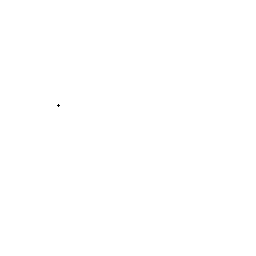

--------------------------------------------------

>>> Generating progress GIF for class: axe at iteration 2000...
[axe]  GIF saved -> jl_fs/stroke/training_progress/iter_2000_axe.gif  (64 strokes, 84 frames)



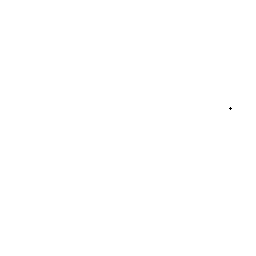

--------------------------------------------------
step  2500  |  train loss 0.3683  |  val loss   0.3847

>>> Generating progress GIF for class: car at iteration 3000...
[car]  GIF saved -> jl_fs/stroke/training_progress/iter_3000_car.gif  (132 strokes, 152 frames)



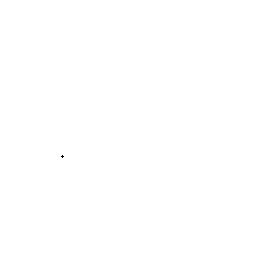

--------------------------------------------------

>>> Generating progress GIF for class: clock at iteration 4000...
[clock]  GIF saved -> jl_fs/stroke/training_progress/iter_4000_clock.gif  (65 strokes, 85 frames)



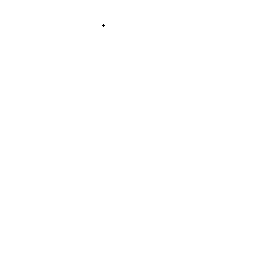

--------------------------------------------------
step  5000  |  train loss 0.3357  |  val loss   0.3481

>>> Generating progress GIF for class: clock at iteration 5000...
[clock]  GIF saved -> jl_fs/stroke/training_progress/iter_5000_clock.gif  (60 strokes, 80 frames)



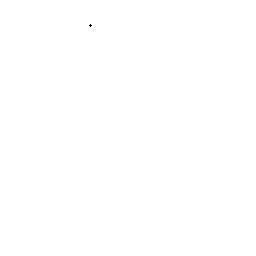

--------------------------------------------------

>>> Generating progress GIF for class: clock at iteration 6000...
[clock]  GIF saved -> jl_fs/stroke/training_progress/iter_6000_clock.gif  (87 strokes, 107 frames)



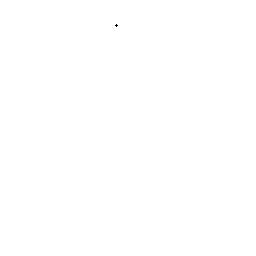

--------------------------------------------------

>>> Generating progress GIF for class: apple at iteration 7000...
[apple]  GIF saved -> jl_fs/stroke/training_progress/iter_7000_apple.gif  (86 strokes, 106 frames)



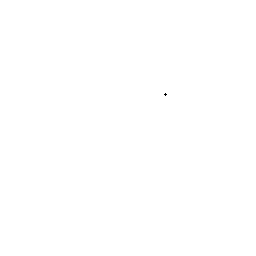

--------------------------------------------------
step  7500  |  train loss 0.4628  |  val loss   0.4672

>>> Generating progress GIF for class: tree at iteration 8000...
[tree]  GIF saved -> jl_fs/stroke/training_progress/iter_8000_tree.gif  (176 strokes, 196 frames)



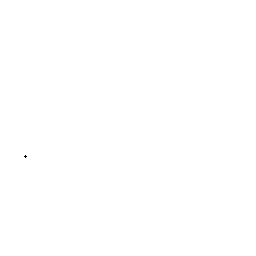

--------------------------------------------------

>>> Generating progress GIF for class: car at iteration 9000...
[car]  GIF saved -> jl_fs/stroke/training_progress/iter_9000_car.gif  (115 strokes, 135 frames)



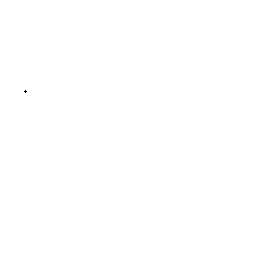

--------------------------------------------------
step 10000  |  train loss 0.2875  |  val loss   0.2743

>>> Generating progress GIF for class: car at iteration 10000...
[car]  GIF saved -> jl_fs/stroke/training_progress/iter_10000_car.gif  (72 strokes, 92 frames)



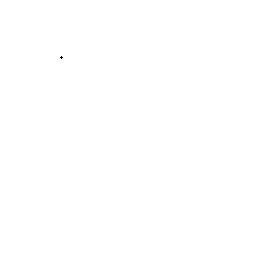

--------------------------------------------------

>>> Generating progress GIF for class: bicycle at iteration 11000...
[bicycle]  GIF saved -> jl_fs/stroke/training_progress/iter_11000_bicycle.gif  (115 strokes, 135 frames)



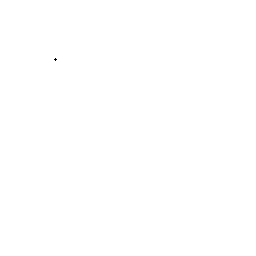

--------------------------------------------------

>>> Generating progress GIF for class: tree at iteration 12000...
[tree]  GIF saved -> jl_fs/stroke/training_progress/iter_12000_tree.gif  (176 strokes, 196 frames)



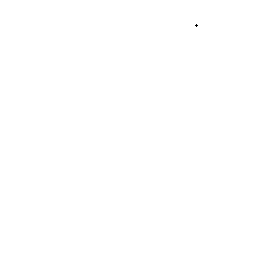

--------------------------------------------------
step 12500  |  train loss 0.2818  |  val loss   0.2759

>>> Generating progress GIF for class: axe at iteration 13000...
[axe]  GIF saved -> jl_fs/stroke/training_progress/iter_13000_axe.gif  (123 strokes, 143 frames)



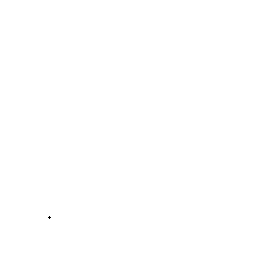

--------------------------------------------------

>>> Generating progress GIF for class: bicycle at iteration 14000...
[bicycle]  GIF saved -> jl_fs/stroke/training_progress/iter_14000_bicycle.gif  (123 strokes, 143 frames)



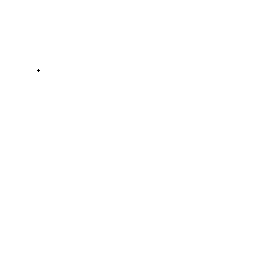

--------------------------------------------------
step 15000  |  train loss 0.2708  |  val loss   0.2681

>>> Generating progress GIF for class: fish at iteration 15000...
[fish]  GIF saved -> jl_fs/stroke/training_progress/iter_15000_fish.gif  (62 strokes, 82 frames)



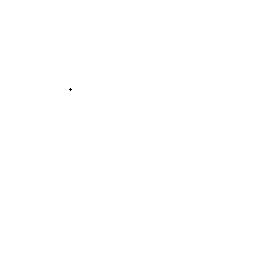

--------------------------------------------------

>>> Generating progress GIF for class: tree at iteration 16000...
[tree]  GIF saved -> jl_fs/stroke/training_progress/iter_16000_tree.gif  (176 strokes, 196 frames)



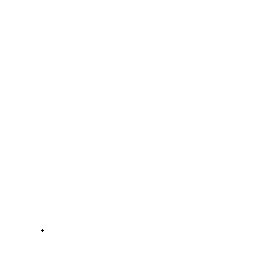

--------------------------------------------------

>>> Generating progress GIF for class: tree at iteration 17000...
[tree]  GIF saved -> jl_fs/stroke/training_progress/iter_17000_tree.gif  (176 strokes, 196 frames)



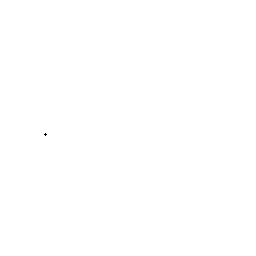

--------------------------------------------------
step 17500  |  train loss 0.2859  |  val loss   0.2771

>>> Generating progress GIF for class: airplane at iteration 18000...
[airplane]  GIF saved -> jl_fs/stroke/training_progress/iter_18000_airplane.gif  (124 strokes, 144 frames)



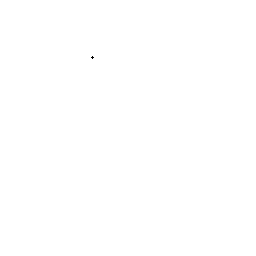

--------------------------------------------------

>>> Generating progress GIF for class: axe at iteration 19000...
[axe]  GIF saved -> jl_fs/stroke/training_progress/iter_19000_axe.gif  (42 strokes, 62 frames)



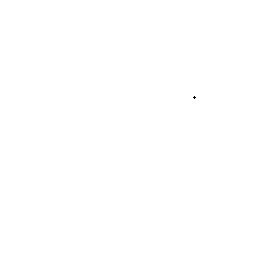

--------------------------------------------------
step 20000  |  train loss 0.3498  |  val loss   0.3327

>>> Generating progress GIF for class: airplane at iteration 20000...
[airplane]  GIF saved -> jl_fs/stroke/training_progress/iter_20000_airplane.gif  (56 strokes, 76 frames)



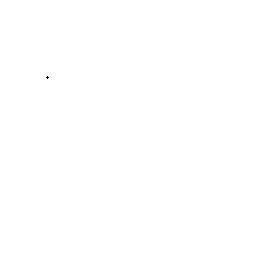

--------------------------------------------------

>>> Generating progress GIF for class: banana at iteration 21000...
[banana]  GIF saved -> jl_fs/stroke/training_progress/iter_21000_banana.gif  (94 strokes, 114 frames)



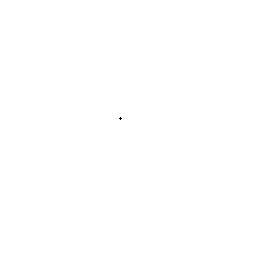

--------------------------------------------------

>>> Generating progress GIF for class: banana at iteration 22000...
[banana]  GIF saved -> jl_fs/stroke/training_progress/iter_22000_banana.gif  (30 strokes, 50 frames)



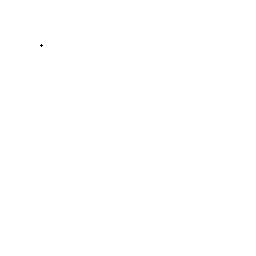

--------------------------------------------------
step 22500  |  train loss 0.2570  |  val loss   0.2461

>>> Generating progress GIF for class: axe at iteration 23000...
[axe]  GIF saved -> jl_fs/stroke/training_progress/iter_23000_axe.gif  (56 strokes, 76 frames)



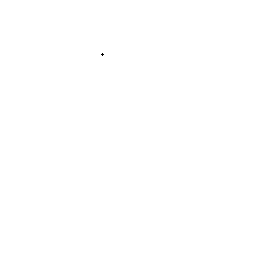

--------------------------------------------------

>>> Generating progress GIF for class: banana at iteration 24000...
[banana]  GIF saved -> jl_fs/stroke/training_progress/iter_24000_banana.gif  (23 strokes, 43 frames)



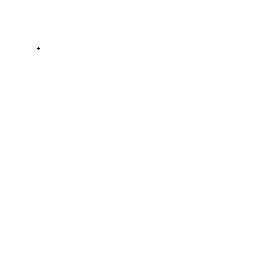

--------------------------------------------------
step 25000  |  train loss 0.2975  |  val loss   0.3058

>>> Generating progress GIF for class: apple at iteration 25000...
[apple]  GIF saved -> jl_fs/stroke/training_progress/iter_25000_apple.gif  (43 strokes, 63 frames)



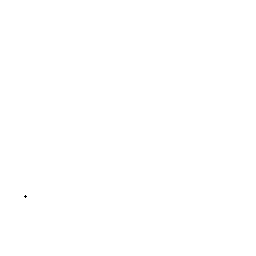

--------------------------------------------------

>>> Generating progress GIF for class: car at iteration 26000...
[car]  GIF saved -> jl_fs/stroke/training_progress/iter_26000_car.gif  (147 strokes, 167 frames)



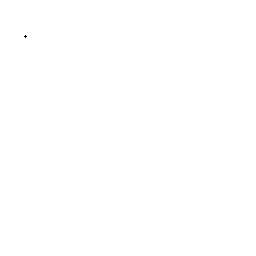

--------------------------------------------------

>>> Generating progress GIF for class: bed at iteration 27000...
[bed]  GIF saved -> jl_fs/stroke/training_progress/iter_27000_bed.gif  (165 strokes, 185 frames)



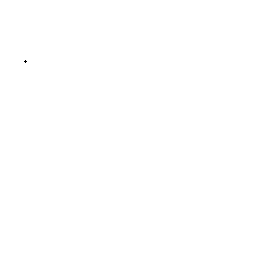

--------------------------------------------------
step 27500  |  train loss 0.2598  |  val loss   0.2665

>>> Generating progress GIF for class: clock at iteration 28000...
[clock]  GIF saved -> jl_fs/stroke/training_progress/iter_28000_clock.gif  (61 strokes, 81 frames)



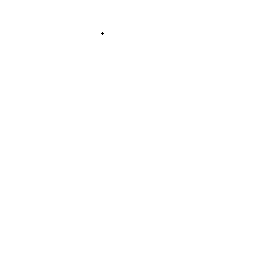

--------------------------------------------------

>>> Generating progress GIF for class: tree at iteration 29000...
[tree]  GIF saved -> jl_fs/stroke/training_progress/iter_29000_tree.gif  (176 strokes, 196 frames)



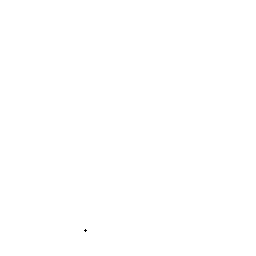

--------------------------------------------------
step 30000  |  train loss 0.2897  |  val loss   0.2695

>>> Generating progress GIF for class: airplane at iteration 30000...
[airplane]  GIF saved -> jl_fs/stroke/training_progress/iter_30000_airplane.gif  (57 strokes, 77 frames)



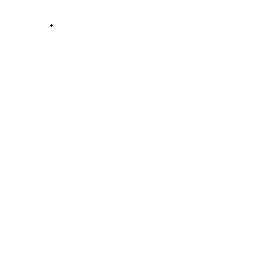

--------------------------------------------------

>>> Generating progress GIF for class: tree at iteration 31000...
[tree]  GIF saved -> jl_fs/stroke/training_progress/iter_31000_tree.gif  (176 strokes, 196 frames)



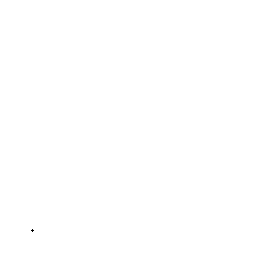

--------------------------------------------------

>>> Generating progress GIF for class: axe at iteration 32000...
[axe]  GIF saved -> jl_fs/stroke/training_progress/iter_32000_axe.gif  (79 strokes, 99 frames)



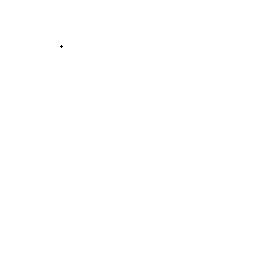

--------------------------------------------------
step 32500  |  train loss 0.3155  |  val loss   0.3126

>>> Generating progress GIF for class: clock at iteration 33000...
[clock]  GIF saved -> jl_fs/stroke/training_progress/iter_33000_clock.gif  (53 strokes, 73 frames)



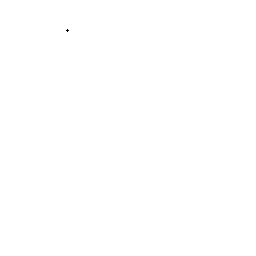

--------------------------------------------------

>>> Generating progress GIF for class: fish at iteration 34000...
[fish]  GIF saved -> jl_fs/stroke/training_progress/iter_34000_fish.gif  (107 strokes, 127 frames)



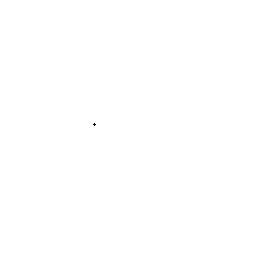

--------------------------------------------------
step 35000  |  train loss 0.2481  |  val loss   0.2559

>>> Generating progress GIF for class: tree at iteration 35000...
[tree]  GIF saved -> jl_fs/stroke/training_progress/iter_35000_tree.gif  (176 strokes, 196 frames)



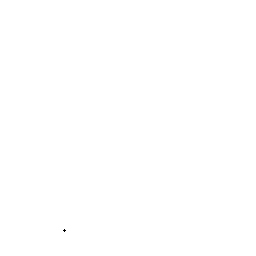

--------------------------------------------------

>>> Generating progress GIF for class: tree at iteration 36000...
[tree]  GIF saved -> jl_fs/stroke/training_progress/iter_36000_tree.gif  (176 strokes, 196 frames)



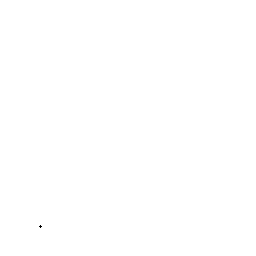

--------------------------------------------------

>>> Generating progress GIF for class: bicycle at iteration 37000...
[bicycle]  GIF saved -> jl_fs/stroke/training_progress/iter_37000_bicycle.gif  (138 strokes, 158 frames)



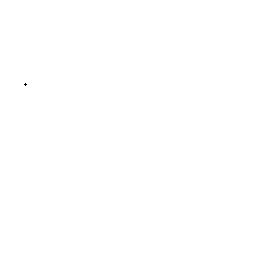

--------------------------------------------------
step 37500  |  train loss 0.2502  |  val loss   0.2572

>>> Generating progress GIF for class: bicycle at iteration 38000...
[bicycle]  GIF saved -> jl_fs/stroke/training_progress/iter_38000_bicycle.gif  (131 strokes, 151 frames)



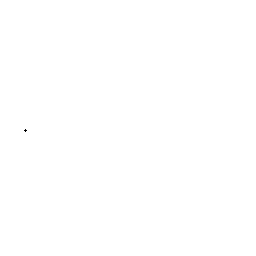

--------------------------------------------------

>>> Generating progress GIF for class: axe at iteration 39000...
[axe]  GIF saved -> jl_fs/stroke/training_progress/iter_39000_axe.gif  (37 strokes, 57 frames)



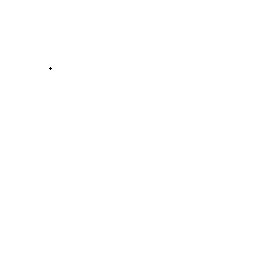

--------------------------------------------------
step 40000  |  train loss 0.2487  |  val loss   0.2512

>>> Generating progress GIF for class: bicycle at iteration 40000...
[bicycle]  GIF saved -> jl_fs/stroke/training_progress/iter_40000_bicycle.gif  (107 strokes, 127 frames)



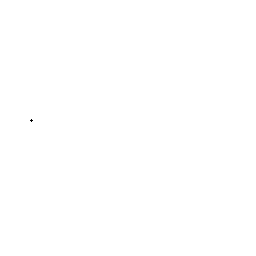

--------------------------------------------------

>>> Generating progress GIF for class: bicycle at iteration 41000...
[bicycle]  GIF saved -> jl_fs/stroke/training_progress/iter_41000_bicycle.gif  (146 strokes, 166 frames)



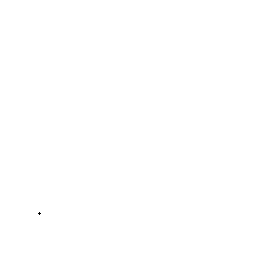

--------------------------------------------------

>>> Generating progress GIF for class: tree at iteration 42000...
[tree]  GIF saved -> jl_fs/stroke/training_progress/iter_42000_tree.gif  (176 strokes, 196 frames)



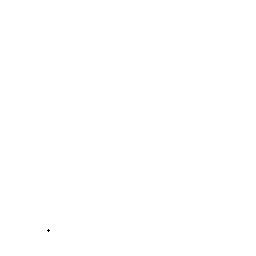

--------------------------------------------------
step 42500  |  train loss 0.3213  |  val loss   0.3278

>>> Generating progress GIF for class: axe at iteration 43000...
[axe]  GIF saved -> jl_fs/stroke/training_progress/iter_43000_axe.gif  (57 strokes, 77 frames)



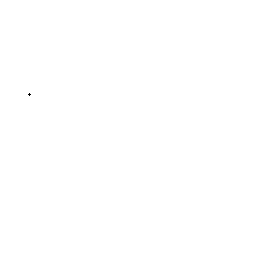

--------------------------------------------------

>>> Generating progress GIF for class: bicycle at iteration 44000...
[bicycle]  GIF saved -> jl_fs/stroke/training_progress/iter_44000_bicycle.gif  (124 strokes, 144 frames)



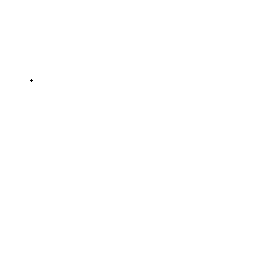

--------------------------------------------------
step 45000  |  train loss 0.2475  |  val loss   0.2353

>>> Generating progress GIF for class: car at iteration 45000...
[car]  GIF saved -> jl_fs/stroke/training_progress/iter_45000_car.gif  (84 strokes, 104 frames)



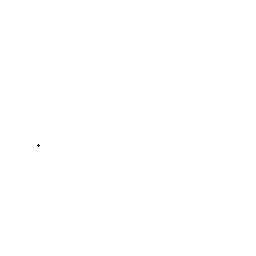

--------------------------------------------------

>>> Generating progress GIF for class: car at iteration 46000...
[car]  GIF saved -> jl_fs/stroke/training_progress/iter_46000_car.gif  (150 strokes, 170 frames)



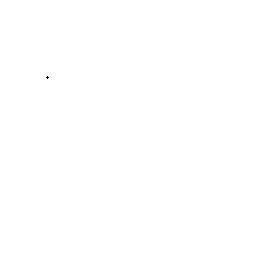

--------------------------------------------------

>>> Generating progress GIF for class: apple at iteration 47000...
[apple]  GIF saved -> jl_fs/stroke/training_progress/iter_47000_apple.gif  (44 strokes, 64 frames)



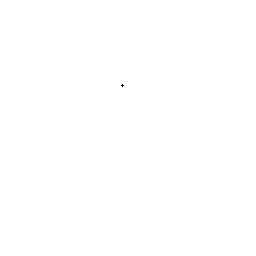

--------------------------------------------------
step 47500  |  train loss 0.2255  |  val loss   0.2167

>>> Generating progress GIF for class: airplane at iteration 48000...
[airplane]  GIF saved -> jl_fs/stroke/training_progress/iter_48000_airplane.gif  (57 strokes, 77 frames)



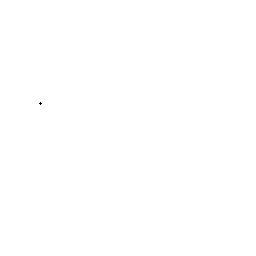

--------------------------------------------------

>>> Generating progress GIF for class: clock at iteration 49000...
[clock]  GIF saved -> jl_fs/stroke/training_progress/iter_49000_clock.gif  (42 strokes, 62 frames)



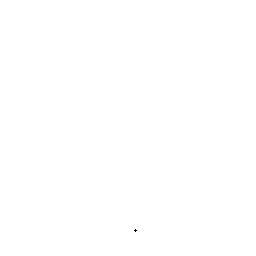

--------------------------------------------------


In [14]:
model = ClassConditionedTransformerModel().to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
 
 
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8  ─  Training loop
# ─────────────────────────────────────────────────────────────────────────────
@torch.no_grad()
def estimate_loss():
    model.eval()
    out = {}
    for split in ["train", "valid"]:
        losses = []
        for _ in range(eval_iters):
            xs, ys, mask, cls_ids = get_batch(split)
            losses.append(model.loss(xs, ys, mask, cls_ids).mean().item())
        out[split] = float(np.mean(losses))
    model.train()
    return out
 
 
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
model.train()

GIF_PROGRESS_DIR = "jl_fs/stroke/training_progress"
os.makedirs(GIF_PROGRESS_DIR, exist_ok=True)
 
for iteration in range(training_iters):
 
    if iteration % eval_interval == 0:
        losses = estimate_loss()
        print(f"step {iteration:>5}  |  "
              f"train loss {losses['train']:.4f}  |  "
              f"val loss   {losses['valid']:.4f}")
    if iteration % 1000 == 0 and iteration > 0:
        # We'll pick a random class to see how the model generalizes
        random_class_idx = np.random.randint(0, num_classes)
        class_name = data_classes[random_class_idx]
        
        # Define path for this specific checkpoint
        temp_gif_path = os.path.join(GIF_PROGRESS_DIR, f"iter_{iteration}_{class_name}.gif")
        
        print(f"\n>>> Generating progress GIF for class: {class_name} at iteration {iteration}...")
        
        # Generate the GIF
        generate_gif(
            model=model,
            class_idx=random_class_idx,
            gif_path=temp_gif_path,
            tau=0.4, # Lower tau usually looks cleaner during training
            canvas=256,
            fps=15
        )
        
        # Display it
        show_gif_inline(temp_gif_path)
        print("-" * 50)
 
    xb, yb, mask, cls_ids = get_batch("train")
    loss = model.loss(xb, yb, mask, cls_ids).mean()
 
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

step 50000  |  train loss 0.1957  |  val loss   0.2133

>>> Generating progress GIF for class: apple at iteration 50000...
[apple]  GIF saved -> jl_fs/stroke/training_progress/iter_50000_apple.gif  (35 strokes, 55 frames)



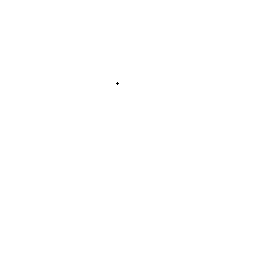

--------------------------------------------------

>>> Generating progress GIF for class: bed at iteration 51000...
[bed]  GIF saved -> jl_fs/stroke/training_progress/iter_51000_bed.gif  (115 strokes, 135 frames)



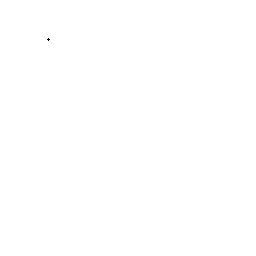

--------------------------------------------------

>>> Generating progress GIF for class: car at iteration 52000...
[car]  GIF saved -> jl_fs/stroke/training_progress/iter_52000_car.gif  (153 strokes, 173 frames)



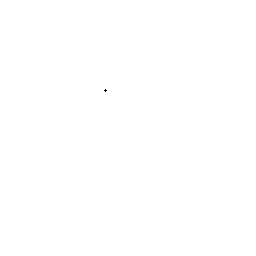

--------------------------------------------------
step 52500  |  train loss 0.2401  |  val loss   0.2164

>>> Generating progress GIF for class: axe at iteration 53000...
[axe]  GIF saved -> jl_fs/stroke/training_progress/iter_53000_axe.gif  (68 strokes, 88 frames)



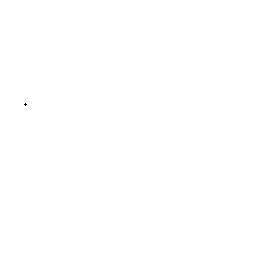

--------------------------------------------------

>>> Generating progress GIF for class: fish at iteration 54000...
[fish]  GIF saved -> jl_fs/stroke/training_progress/iter_54000_fish.gif  (69 strokes, 89 frames)



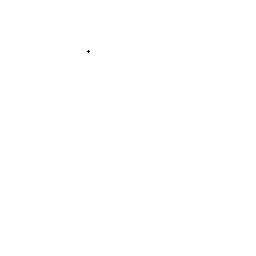

--------------------------------------------------
step 55000  |  train loss 0.3172  |  val loss   0.3096

>>> Generating progress GIF for class: clock at iteration 55000...
[clock]  GIF saved -> jl_fs/stroke/training_progress/iter_55000_clock.gif  (71 strokes, 91 frames)



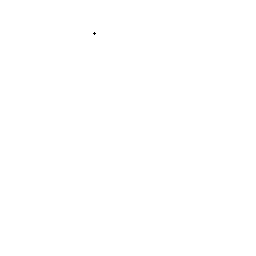

--------------------------------------------------

>>> Generating progress GIF for class: airplane at iteration 56000...
[airplane]  GIF saved -> jl_fs/stroke/training_progress/iter_56000_airplane.gif  (109 strokes, 129 frames)



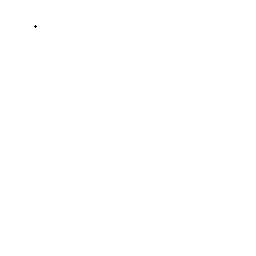

--------------------------------------------------

>>> Generating progress GIF for class: tree at iteration 57000...
[tree]  GIF saved -> jl_fs/stroke/training_progress/iter_57000_tree.gif  (176 strokes, 196 frames)



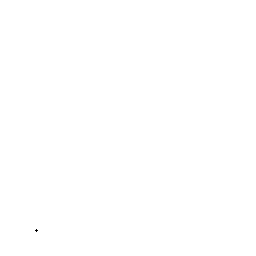

--------------------------------------------------
step 57500  |  train loss 0.2180  |  val loss   0.2093

>>> Generating progress GIF for class: apple at iteration 58000...
[apple]  GIF saved -> jl_fs/stroke/training_progress/iter_58000_apple.gif  (35 strokes, 55 frames)



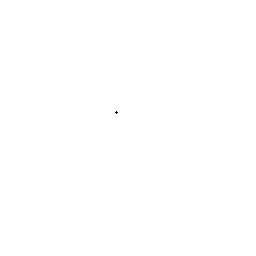

--------------------------------------------------

>>> Generating progress GIF for class: clock at iteration 59000...
[clock]  GIF saved -> jl_fs/stroke/training_progress/iter_59000_clock.gif  (116 strokes, 136 frames)



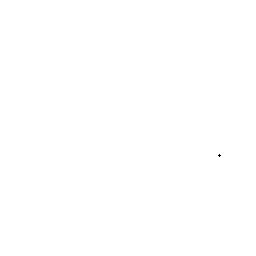

--------------------------------------------------
step 60000  |  train loss 0.2046  |  val loss   0.2008

>>> Generating progress GIF for class: fish at iteration 60000...
[fish]  GIF saved -> jl_fs/stroke/training_progress/iter_60000_fish.gif  (86 strokes, 106 frames)



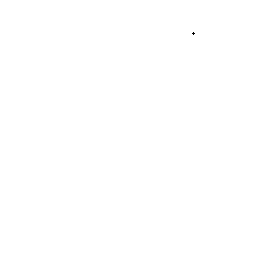

--------------------------------------------------

>>> Generating progress GIF for class: car at iteration 61000...
[car]  GIF saved -> jl_fs/stroke/training_progress/iter_61000_car.gif  (128 strokes, 148 frames)



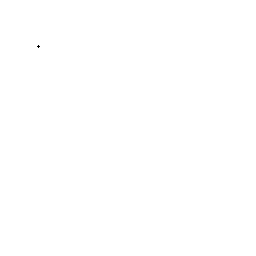

--------------------------------------------------

>>> Generating progress GIF for class: airplane at iteration 62000...
[airplane]  GIF saved -> jl_fs/stroke/training_progress/iter_62000_airplane.gif  (118 strokes, 138 frames)



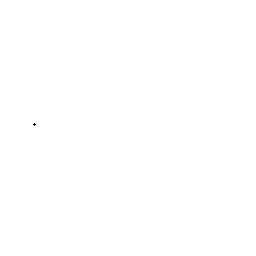

--------------------------------------------------
step 62500  |  train loss 0.2823  |  val loss   0.3003

>>> Generating progress GIF for class: axe at iteration 63000...
[axe]  GIF saved -> jl_fs/stroke/training_progress/iter_63000_axe.gif  (56 strokes, 76 frames)



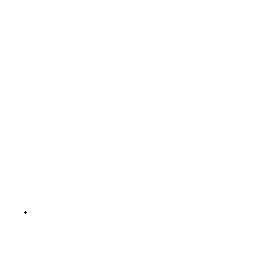

--------------------------------------------------

>>> Generating progress GIF for class: tree at iteration 64000...
[tree]  GIF saved -> jl_fs/stroke/training_progress/iter_64000_tree.gif  (176 strokes, 196 frames)



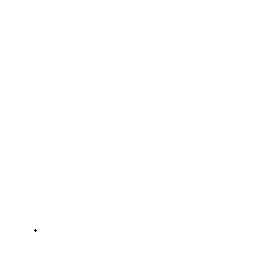

--------------------------------------------------
step 65000  |  train loss 0.1911  |  val loss   0.2063

>>> Generating progress GIF for class: axe at iteration 65000...
[axe]  GIF saved -> jl_fs/stroke/training_progress/iter_65000_axe.gif  (39 strokes, 59 frames)



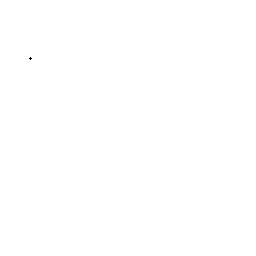

--------------------------------------------------

>>> Generating progress GIF for class: bicycle at iteration 66000...
[bicycle]  GIF saved -> jl_fs/stroke/training_progress/iter_66000_bicycle.gif  (150 strokes, 170 frames)



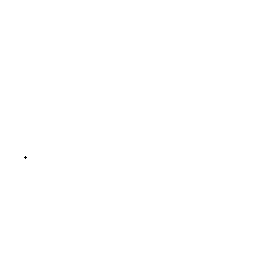

--------------------------------------------------

>>> Generating progress GIF for class: clock at iteration 67000...
[clock]  GIF saved -> jl_fs/stroke/training_progress/iter_67000_clock.gif  (55 strokes, 75 frames)



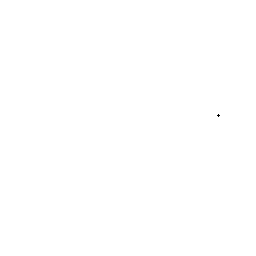

--------------------------------------------------
step 67500  |  train loss 0.2888  |  val loss   0.3087

>>> Generating progress GIF for class: fish at iteration 68000...
[fish]  GIF saved -> jl_fs/stroke/training_progress/iter_68000_fish.gif  (96 strokes, 116 frames)



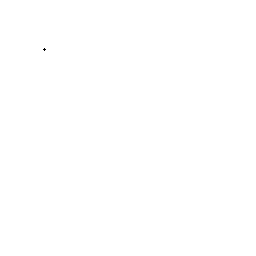

--------------------------------------------------

>>> Generating progress GIF for class: fish at iteration 69000...
[fish]  GIF saved -> jl_fs/stroke/training_progress/iter_69000_fish.gif  (88 strokes, 108 frames)



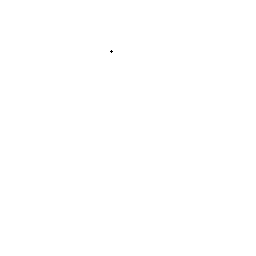

--------------------------------------------------
step 70000  |  train loss 0.2004  |  val loss   0.2027

>>> Generating progress GIF for class: bed at iteration 70000...
[bed]  GIF saved -> jl_fs/stroke/training_progress/iter_70000_bed.gif  (122 strokes, 142 frames)



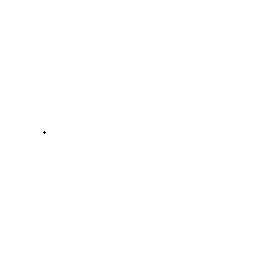

--------------------------------------------------

>>> Generating progress GIF for class: airplane at iteration 71000...
[airplane]  GIF saved -> jl_fs/stroke/training_progress/iter_71000_airplane.gif  (143 strokes, 163 frames)



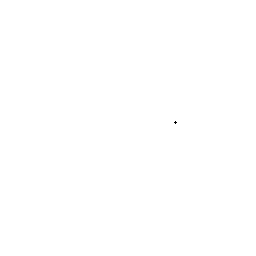

--------------------------------------------------

>>> Generating progress GIF for class: axe at iteration 72000...
[axe]  GIF saved -> jl_fs/stroke/training_progress/iter_72000_axe.gif  (64 strokes, 84 frames)



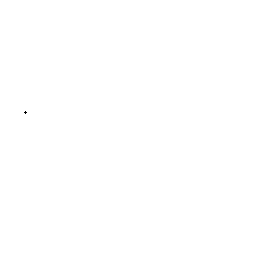

--------------------------------------------------
step 72500  |  train loss 0.2255  |  val loss   0.2253

>>> Generating progress GIF for class: airplane at iteration 73000...
[airplane]  GIF saved -> jl_fs/stroke/training_progress/iter_73000_airplane.gif  (95 strokes, 115 frames)



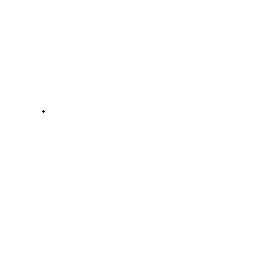

--------------------------------------------------

>>> Generating progress GIF for class: fish at iteration 74000...
[fish]  GIF saved -> jl_fs/stroke/training_progress/iter_74000_fish.gif  (72 strokes, 92 frames)



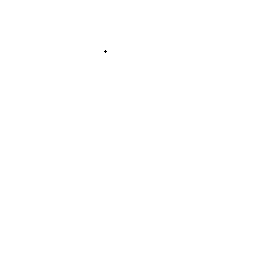

--------------------------------------------------
step 75000  |  train loss 0.2338  |  val loss   0.2491

>>> Generating progress GIF for class: banana at iteration 75000...
[banana]  GIF saved -> jl_fs/stroke/training_progress/iter_75000_banana.gif  (44 strokes, 64 frames)



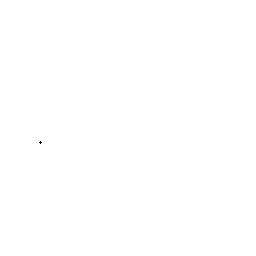

--------------------------------------------------

>>> Generating progress GIF for class: car at iteration 76000...
[car]  GIF saved -> jl_fs/stroke/training_progress/iter_76000_car.gif  (117 strokes, 137 frames)



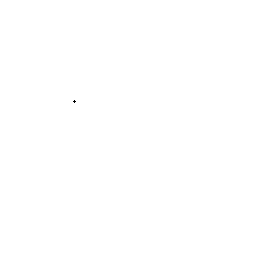

--------------------------------------------------

>>> Generating progress GIF for class: car at iteration 77000...
[car]  GIF saved -> jl_fs/stroke/training_progress/iter_77000_car.gif  (118 strokes, 138 frames)



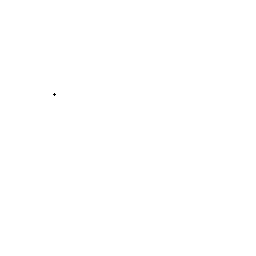

--------------------------------------------------
step 77500  |  train loss 0.2669  |  val loss   0.2643

>>> Generating progress GIF for class: clock at iteration 78000...
[clock]  GIF saved -> jl_fs/stroke/training_progress/iter_78000_clock.gif  (70 strokes, 90 frames)



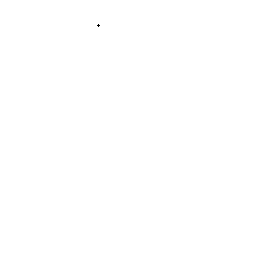

--------------------------------------------------

>>> Generating progress GIF for class: clock at iteration 79000...
[clock]  GIF saved -> jl_fs/stroke/training_progress/iter_79000_clock.gif  (34 strokes, 54 frames)



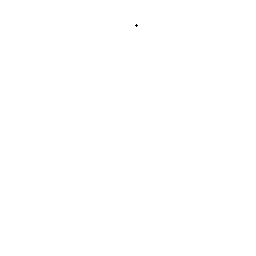

--------------------------------------------------
step 80000  |  train loss 0.3181  |  val loss   0.2943

>>> Generating progress GIF for class: fish at iteration 80000...
[fish]  GIF saved -> jl_fs/stroke/training_progress/iter_80000_fish.gif  (49 strokes, 69 frames)



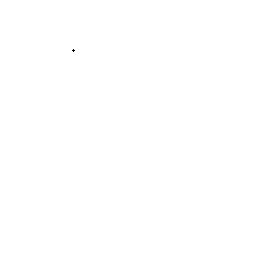

--------------------------------------------------

>>> Generating progress GIF for class: bicycle at iteration 81000...
[bicycle]  GIF saved -> jl_fs/stroke/training_progress/iter_81000_bicycle.gif  (114 strokes, 134 frames)



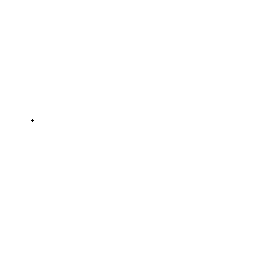

--------------------------------------------------

>>> Generating progress GIF for class: tree at iteration 82000...
[tree]  GIF saved -> jl_fs/stroke/training_progress/iter_82000_tree.gif  (176 strokes, 196 frames)



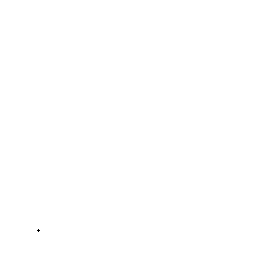

--------------------------------------------------
step 82500  |  train loss 0.3573  |  val loss   0.3625

>>> Generating progress GIF for class: car at iteration 83000...
[car]  GIF saved -> jl_fs/stroke/training_progress/iter_83000_car.gif  (91 strokes, 111 frames)



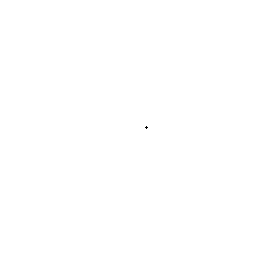

--------------------------------------------------

>>> Generating progress GIF for class: tree at iteration 84000...
[tree]  GIF saved -> jl_fs/stroke/training_progress/iter_84000_tree.gif  (176 strokes, 196 frames)



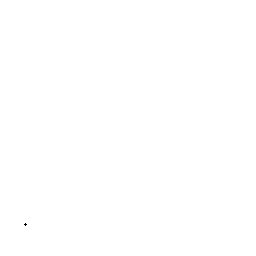

--------------------------------------------------
step 85000  |  train loss 0.1929  |  val loss   0.1910

>>> Generating progress GIF for class: bed at iteration 85000...
[bed]  GIF saved -> jl_fs/stroke/training_progress/iter_85000_bed.gif  (72 strokes, 92 frames)



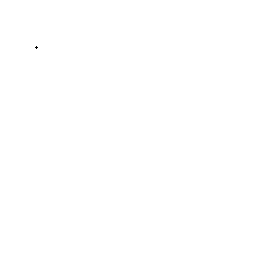

--------------------------------------------------

>>> Generating progress GIF for class: bed at iteration 86000...
[bed]  GIF saved -> jl_fs/stroke/training_progress/iter_86000_bed.gif  (75 strokes, 95 frames)



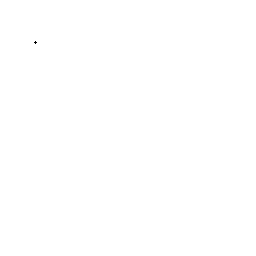

--------------------------------------------------

>>> Generating progress GIF for class: axe at iteration 87000...
[axe]  GIF saved -> jl_fs/stroke/training_progress/iter_87000_axe.gif  (63 strokes, 83 frames)



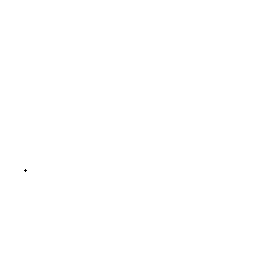

--------------------------------------------------
step 87500  |  train loss 0.1767  |  val loss   0.1765

>>> Generating progress GIF for class: fish at iteration 88000...
[fish]  GIF saved -> jl_fs/stroke/training_progress/iter_88000_fish.gif  (39 strokes, 59 frames)



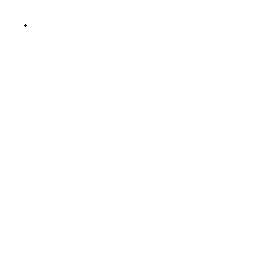

--------------------------------------------------

>>> Generating progress GIF for class: bed at iteration 89000...
[bed]  GIF saved -> jl_fs/stroke/training_progress/iter_89000_bed.gif  (63 strokes, 83 frames)



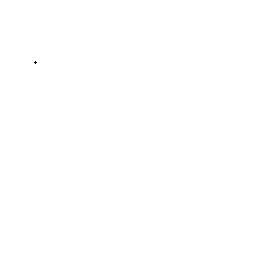

--------------------------------------------------
step 90000  |  train loss 0.2369  |  val loss   0.2352

>>> Generating progress GIF for class: apple at iteration 90000...
[apple]  GIF saved -> jl_fs/stroke/training_progress/iter_90000_apple.gif  (51 strokes, 71 frames)



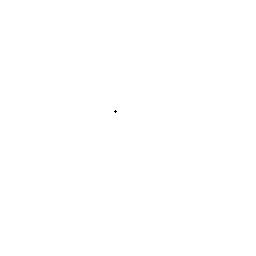

--------------------------------------------------

>>> Generating progress GIF for class: apple at iteration 91000...
[apple]  GIF saved -> jl_fs/stroke/training_progress/iter_91000_apple.gif  (50 strokes, 70 frames)



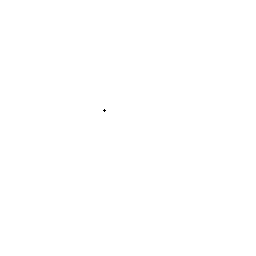

--------------------------------------------------

>>> Generating progress GIF for class: airplane at iteration 92000...
[airplane]  GIF saved -> jl_fs/stroke/training_progress/iter_92000_airplane.gif  (89 strokes, 109 frames)



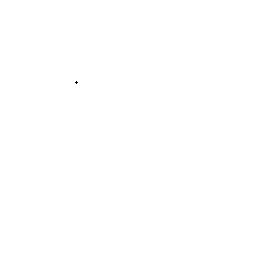

--------------------------------------------------
step 92500  |  train loss 0.1901  |  val loss   0.1944

>>> Generating progress GIF for class: axe at iteration 93000...
[axe]  GIF saved -> jl_fs/stroke/training_progress/iter_93000_axe.gif  (57 strokes, 77 frames)



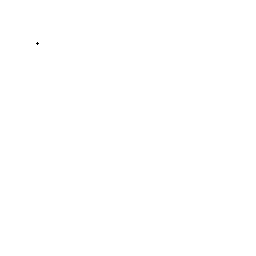

--------------------------------------------------

>>> Generating progress GIF for class: tree at iteration 94000...
[tree]  GIF saved -> jl_fs/stroke/training_progress/iter_94000_tree.gif  (169 strokes, 189 frames)



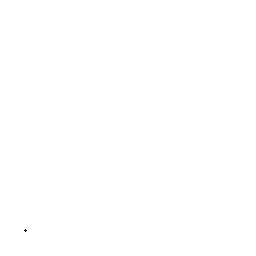

--------------------------------------------------
step 95000  |  train loss 0.2156  |  val loss   0.2066

>>> Generating progress GIF for class: clock at iteration 95000...
[clock]  GIF saved -> jl_fs/stroke/training_progress/iter_95000_clock.gif  (46 strokes, 66 frames)



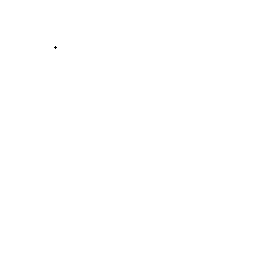

--------------------------------------------------

>>> Generating progress GIF for class: airplane at iteration 96000...
[airplane]  GIF saved -> jl_fs/stroke/training_progress/iter_96000_airplane.gif  (139 strokes, 159 frames)



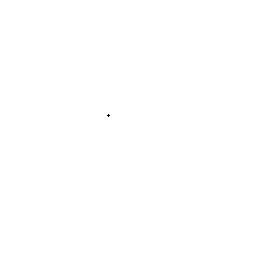

--------------------------------------------------

>>> Generating progress GIF for class: apple at iteration 97000...
[apple]  GIF saved -> jl_fs/stroke/training_progress/iter_97000_apple.gif  (63 strokes, 83 frames)



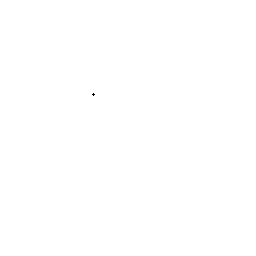

--------------------------------------------------
step 97500  |  train loss 0.2232  |  val loss   0.2127

>>> Generating progress GIF for class: clock at iteration 98000...
[clock]  GIF saved -> jl_fs/stroke/training_progress/iter_98000_clock.gif  (89 strokes, 109 frames)



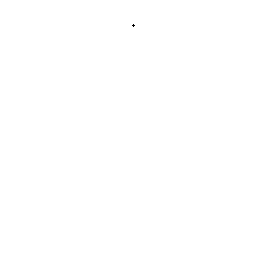

--------------------------------------------------

>>> Generating progress GIF for class: fish at iteration 99000...
[fish]  GIF saved -> jl_fs/stroke/training_progress/iter_99000_fish.gif  (100 strokes, 120 frames)



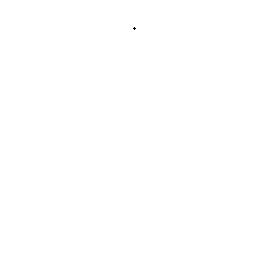

--------------------------------------------------


In [15]:
# continue from where you stopped
start_iter = 50000
end_iter = 100000   # +50k more

for iteration in range(start_iter, end_iter):

    if iteration % eval_interval == 0:
        losses = estimate_loss()
        print(f"step {iteration:>5}  |  "
              f"train loss {losses['train']:.4f}  |  "
              f"val loss   {losses['valid']:.4f}")

    if iteration % 1000 == 0:
        random_class_idx = np.random.randint(0, num_classes)
        class_name = data_classes[random_class_idx]

        temp_gif_path = os.path.join(
            GIF_PROGRESS_DIR,
            f"iter_{iteration}_{class_name}.gif"
        )

        print(f"\n>>> Generating progress GIF for class: {class_name} at iteration {iteration}...")

        generate_gif(
            model=model,
            class_idx=random_class_idx,
            gif_path=temp_gif_path,
            tau=0.4,
            canvas=256,
            fps=15
        )

        show_gif_inline(temp_gif_path)
        print("-" * 50)

    xb, yb, mask, cls_ids = get_batch("train")
    loss = model.loss(xb, yb, mask, cls_ids).mean()

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

In [18]:
os.makedirs('jl_fs/stroke/model_store', exist_ok=True)
CKPT_PATH = "jl_fs/stroke/model_store/model_10class.pth"
torch.save({
    "model": model.state_dict(),
    'optimizer': optimizer.state_dict(),
    "block_size":       block_size,
    "x_std":            x_std,
    "y_std":            y_std,
    "data_classes":     data_classes,
}, CKPT_PATH)
print(f"\nCheckpoint saved -> {CKPT_PATH}")


Checkpoint saved -> jl_fs/stroke/model_store/model_10class.pth


In [12]:
def generate_frames(model, class_idx, tau=0.4, canvas=256, hold_frames=20, factor=0.1):
    model.eval()

    cls_tensor = torch.tensor([class_idx], dtype=torch.long, device=device)
    x_init = torch.zeros(1, 1, 3, device=device)

    with torch.no_grad():
        generated = model.generate(
            x_init,
            cls_tensor,
            max_new_tokens=block_size - 1,
            tau=tau,
            break_eos=True,
        )

    strokes = generated[0].cpu().numpy()

    strokes[:, 0] *= x_std
    strokes[:, 1] *= y_std

    pts = strokes_to_abs_pixels(strokes, factor=factor, canvas=canvas)

    frames = [
        np.array(render_frame(pts[:t+1], canvas=canvas))
        for t in range(len(pts))
    ]

    frames += [frames[-1]] * hold_frames
    return frames

In [13]:
def combine_gif_grid(frames_list):
    max_len = max(len(frames) for frames in frames_list)

    padded = []
    for frames in frames_list:
        if len(frames) < max_len:
            frames = frames + [frames[-1]] * (max_len - len(frames))
        padded.append(frames)

    combined_frames = []

    for t in range(max_len):
        row = [padded[i][t] for i in range(5)]
        grid = np.concatenate(row, axis=1)
        combined_frames.append(grid)

    return combined_frames

In [14]:
def add_title(frames, title):
    new_frames = []

    for frame in frames:
        img = Image.fromarray(frame)
        draw = ImageDraw.Draw(img)
        draw.text((10, 10), title, fill=(255, 0, 0))
        new_frames.append(np.array(img))

    return new_frames

In [15]:
def generate_class_grid_gif(model, class_idx, class_name, save_path):
    print(f"Generating for class: {class_name}")

    frames_list = [
        generate_frames(model, class_idx, tau=0.4)
        for _ in range(5)
    ]

    combined = combine_gif_grid(frames_list)
    combined = add_title(combined, f"Class: {class_name}")

    imageio.mimsave(save_path, combined, fps=15, loop=0)

    print(f"Saved: {save_path}")

In [16]:
checkpoint = torch.load("jl_fs/stroke/model_store/model_10class.pth", map_location=device)

model = ClassConditionedTransformerModel().to(device)
model.load_state_dict(checkpoint['model'])

model.eval()

print("✅ Model loaded successfully")

✅ Model loaded successfully


In [26]:
SAVE_DIR = "jl_fs/stroke/class_grid_gifs"
os.makedirs(SAVE_DIR, exist_ok=True)

# torch.manual_seed(None)
# np.random.seed(None)

for class_idx, class_name in enumerate(data_classes):
    save_path = os.path.join(SAVE_DIR, f"{class_name}.gif")

    generate_class_grid_gif(
        model,
        class_idx,
        class_name,
        save_path
    )

Generating for class: airplane
Saved: jl_fs/stroke/class_grid_gifs/airplane.gif
Generating for class: apple
Saved: jl_fs/stroke/class_grid_gifs/apple.gif
Generating for class: axe
Saved: jl_fs/stroke/class_grid_gifs/axe.gif
Generating for class: banana
Saved: jl_fs/stroke/class_grid_gifs/banana.gif
Generating for class: bed
Saved: jl_fs/stroke/class_grid_gifs/bed.gif
Generating for class: bicycle
Saved: jl_fs/stroke/class_grid_gifs/bicycle.gif
Generating for class: car
Saved: jl_fs/stroke/class_grid_gifs/car.gif
Generating for class: clock
Saved: jl_fs/stroke/class_grid_gifs/clock.gif
Generating for class: fish
Saved: jl_fs/stroke/class_grid_gifs/fish.gif
Generating for class: tree
Saved: jl_fs/stroke/class_grid_gifs/tree.gif
